# <center>**Home Loan Default Prediction**</center>

**member name** :  **Chethan S (Individual)**  

**project deadline:** : 15 days (11 April 2026 to 26 April 2026) 

**team id    :**   **PTID-CDS-MAR-26-4096**

**project id :**  **PRCP-1006-HomeLoanDefault**   

**project submission date** :  **25 April 2026**

**dataset used during project   :** [Click Here](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1006-HomeLoanDef.zip)

---


| column name | description |
| --- | --- |
| **SK_ID_CURR** | unique identifier for each loan application (primary key across all tables). |
| **TARGET** | target variable — 1 = client had payment difficulties (default), 0 = repaid on time. |
| **NAME_CONTRACT_TYPE** | type of loan: cash loans or revolving loans. |
| **CODE_GENDER** | gender of the client (m, f, or xna — xna treated as missing). |
| **FLAG_OWN_CAR** | whether the client owns a car (y or n). |
| **FLAG_OWN_REALTY** | whether the client owns real estate property (y or n). |
| **CNT_CHILDREN** | number of children the client has. |
| **AMT_INCOME_TOTAL** | total annual income of the client. |
| **AMT_CREDIT** | total loan credit amount applied for. |
| **AMT_ANNUITY** | annual repayment amount (loan annuity). |
| **AMT_GOODS_PRICE** | price of goods for which the loan is applied. |
| **NAME_INCOME_TYPE** | income source type: working, commercial associate, pensioner, state servant, etc. |
| **NAME_EDUCATION_TYPE** | highest education level of the client. |
| **NAME_FAMILY_STATUS** | marital status: married, single, civil marriage, widow, separated. |
| **NAME_HOUSING_TYPE** | type of housing the client lives in. |
| **DAYS_BIRTH** | client age in days (negative — counted from application date). |
| **DAYS_EMPLOYED** | days the client has been employed (negative). 365243 is an anomaly flag for unemployed. |
| **DAYS_ID_PUBLISH** | days since the client's id was last changed (negative). |
| **EXT_SOURCE_1** | normalised external credit score from source 1 (third-party rating). |
| **EXT_SOURCE_2** | normalised external credit score from source 2 (third-party rating). |
| **EXT_SOURCE_3** | normalised external credit score from source 3 (third-party rating). |
| **CNT_FAM_MEMBERS** | total number of family members. |
| **REGION_RATING_CLIENT** | home credit's regional rating where client lives (1=best, 3=worst). |
| **AGE_YEARS** | engineered — client age in years from DAYS_BIRTH. |
| **CREDIT_INCOME_RATIO** | engineered — ratio of credit amount to annual income (debt burden indicator). |
| **ANNUITY_INCOME_RATIO** | engineered — ratio of annuity to income (affordability indicator). |
| **CREDIT_GOODS_RATIO** | engineered — ratio of credit to goods price. |
| **EMPLOYED_YEARS** | engineered — employment duration in years. |
| **EXT_SOURCE_MEAN** | engineered — average of all three external credit scores. |
| **INCOME_PER_PERSON** | engineered — income divided by family size. |
| **bureau_loan_count** | aggregated from bureau — total number of prior credits. |
| **bureau_total_debt** | aggregated from bureau — total outstanding debt across all bureau records. |
| **bureau_max_day_overdue** | aggregated from bureau — worst overdue days in bureau history. |
| **bureau_debt_ratio** | aggregated from bureau — ratio of total debt to total credit. |
| **prev_app_count** | aggregated from previous_application — total past loan applications. |
| **prev_approved_count** | aggregated — number of previously approved applications. |
| **prev_refused_count** | aggregated — number of previously refused applications. |
| **prev_approval_rate** | aggregated — fraction of past applications that were approved. |
| **pos_max_dpd** | aggregated from POS_CASH — maximum days past due on pos/cash loans. |
| **pos_months_overdue** | aggregated — total months where pos/cash dpd > 0. |
| **cc_avg_utilisation** | aggregated from credit_card — average credit utilisation ratio. |
| **cc_max_dpd** | aggregated from credit_card — worst days past due on credit card. |
| **inst_late_payment_rate** | aggregated from installments — fraction of installments paid late. |
| **inst_max_days_late** | aggregated — longest delay on any single installment payment. |
| **inst_total_shortfall** | aggregated — cumulative underpayment across all installments. |


**this project works well with the following versions:**

---
* Python       :3.13.9
* NumPy        : 2.3.5
* Pandas       : 2.3.3
* Matplotlib   : 3.10.6
* Seaborn      : 0.13.2
* Scikit-learn : 1.7.2
* XGBoost      : 3.2.0

------


**here's the step by step structure we follow during project :**

---

**Task 1:- Perform Complete Exploratory Data Analysis (EDA)**

1. `Import Required Libraries`  
2. `Load Dataset`  
3. `Data Inspection`  
4. `Data Cleaning`  
5. `Univariate Analysis`  
6. `Bivariate & Multivariate Analysis`  
7. `Submit Detailed EDA Report`

**Task 2:- Predict Home Loan Default**

8. `Multi-Table Feature Aggregation`  
9. `Data Preprocessing for Machine Learning`  
10. `Train Logistic Regression Model (Baseline Model)`  
11. `Build and Compare Multiple Models`  
12. `Model Evaluation & Comparison`  
13. `Select Best Model`  
14. `Summary Report`  

**Task 3:- Business Insights and Impact Analysis**

15. `Feature Importance Analysis`  
16. `Business Recommendations`  
17. `Model Impact on Business Growth`  


## 1. importing required libraries for data analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. load data

In [2]:
# using 20% of data for faster iteration
SAMPLE_FRAC  = 0.20
RANDOM_STATE = 42
USE_SAMPLING = True

print(f"sampling enabled : {USE_SAMPLING}") 
print(f"sample fraction  : {SAMPLE_FRAC*100:.0f}% of data" if USE_SAMPLING else "using full dataset")

sampling enabled : True
sample fraction  : 20% of data


In [3]:
application  = pd.read_csv('/dataset/application_train.csv')
bureau       = pd.read_csv('/dataset/bureau.csv')
bureau_bal   = pd.read_csv('/dataset/bureau_balance.csv')
credit_card  = pd.read_csv('/dataset/credit_card_balance.csv')
pos_cash     = pd.read_csv('/dataset/POS_CASH_balance.csv')
prev_app     = pd.read_csv('/dataset/previous_application.csv')
installments = pd.read_csv('/dataset/installments_payments.csv')

if USE_SAMPLING:
    application = application.groupby('TARGET', group_keys=False).apply(
        lambda x: x.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    ).reset_index(drop=True)

    valid_ids    = set(application['SK_ID_CURR'])
    bureau       = bureau[bureau['SK_ID_CURR'].isin(valid_ids)].reset_index(drop=True)
    prev_app     = prev_app[prev_app['SK_ID_CURR'].isin(valid_ids)].reset_index(drop=True)
    pos_cash     = pos_cash[pos_cash['SK_ID_CURR'].isin(valid_ids)].reset_index(drop=True)
    credit_card  = credit_card[credit_card['SK_ID_CURR'].isin(valid_ids)].reset_index(drop=True)
    installments = installments[installments['SK_ID_CURR'].isin(valid_ids)].reset_index(drop=True)

    valid_bureau_ids = set(bureau['SK_ID_BUREAU'])
    bureau_bal   = bureau_bal[bureau_bal['SK_ID_BUREAU'].isin(valid_bureau_ids)].reset_index(drop=True)

    print(f"\n sampling applied — {SAMPLE_FRAC*100:.0f}% of data retained")

print(f"application_train    : {application.shape}")
print(f"bureau               : {bureau.shape}")
print(f"bureau_balance       : {bureau_bal.shape}")
print(f"credit_card_balance  : {credit_card.shape}")
print(f"POS_CASH_balance     : {pos_cash.shape}")
print(f"previous_application : {prev_app.shape}")
print(f"installments_payments: {installments.shape}")


 sampling applied — 20% of data retained
application_train    : (61502, 122)
bureau               : (291636, 17)
bureau_balance       : (2930823, 3)
credit_card_balance  : (642915, 23)
POS_CASH_balance     : (1711380, 8)
previous_application : (282901, 37)
installments_payments: (2316601, 8)


## 3. data inspection

In [4]:
print("=== APPLICATION TRAIN ==="); display(application.head(3))
print("=== BUREAU ===");            display(bureau.head(3))
print("=== BUREAU BALANCE ===");    display(bureau_bal.head(3))
print("=== CREDIT CARD ===");       display(credit_card.head(3))
print("=== POS CASH ===");          display(pos_cash.head(3))
print("=== PREVIOUS APPLICATION ==="); display(prev_app.head(3))
print("=== INSTALLMENTS ===");      display(installments.head(3))

=== APPLICATION TRAIN ===


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,333721,0,Cash loans,M,Y,Y,1,292500.0,1102500.0,32364.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,110157,0,Revolving loans,F,N,Y,0,270000.0,720000.0,36000.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
2,276815,0,Revolving loans,F,Y,Y,1,135000.0,360000.0,18000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


=== BUREAU ===


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,162297,5714469,Closed,currency 1,-1896,0,-1684.0,-1710.0,14985.0,0,76878.45,0.0,0.0,0.0,Consumer credit,-1710,NaN
1,162297,5714470,Closed,currency 1,-1146,0,-811.0,-840.0,0.0,0,103007.70,0.0,0.0,0.0,Consumer credit,-840,NaN
2,162297,5714471,Active,currency 1,-1146,0,-484.0,NaN,0.0,0,4500.00,0.0,0.0,0.0,Credit card,-690,NaN


=== BUREAU BALANCE ===


...

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1715348,367990,-33,36.0,35.0,Active,0,0
1,2341044,334279,-35,36.0,35.0,Active,0,0
2,2328294,287361,-32,12.0,12.0,Active,0,0


=== PREVIOUS APPLICATION ===


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
1,2367563,342292,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,15,...,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
2,2257824,161140,Cash loans,13832.775,211500.0,246397.5,NaN,211500.0,FRIDAY,10,...,XNA,30.0,middle,Cash X-Sell: middle,365243.0,-785.0,85.0,-725.0,-721.0,1.0


=== INSTALLMENTS ===


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
1,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
2,1618622,128303,1.0,5,-2807.0,-2807.0,6523.425,6523.425


In [5]:
application.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
61497,109562,1,Cash loans,M,Y,Y,1,427500.0,730017.0,27184.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
61498,240374,1,Cash loans,F,N,N,1,94500.0,189621.0,12802.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
61499,285036,1,Revolving loans,M,N,Y,0,90000.0,247500.0,12375.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
61500,327867,1,Cash loans,F,N,Y,0,67500.0,213322.5,16983.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
61501,168824,1,Cash loans,F,N,N,3,112500.0,1205896.5,35388.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0


In [6]:
application.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61502 entries, 0 to 61501
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 101.0 MB


In [7]:
application.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,61502.000000,61502.000000,61502.000000,6.150200e+04,6.150200e+04,61499.000000,6.146300e+04,61502.000000,61502.000000,61502.000000,...,61502.000000,61502.000000,61502.000000,61502.000000,53206.000000,53206.000000,53206.000000,53206.000000,53206.000000,53206.000000
mean,278389.696969,0.080729,0.418328,1.681084e+05,5.988498e+05,27174.999650,5.382950e+05,0.020788,-16008.053754,63589.060437,...,0.008065,0.000569,0.000585,0.000228,0.006014,0.006935,0.034395,0.257020,0.262264,1.898526
std,102715.082755,0.272421,0.723055,1.026462e+05,4.005240e+05,14549.302446,3.677978e+05,0.013820,4363.240872,141072.749040,...,0.089442,0.023849,0.024187,0.015086,0.082494,0.110397,0.201724,0.888907,0.614219,1.866411
min,100010.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1980.000000,4.500000e+04,0.000290,-25196.000000,-17546.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189343.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16551.000000,2.385000e+05,0.010006,-19662.000000,-2741.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278460.500000,0.000000,0.000000,1.476000e+05,5.175000e+05,24961.500000,4.500000e+05,0.018850,-15690.500000,-1210.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367608.750000,0.000000,1.000000,2.025000e+05,8.086500e+05,34643.250000,6.795000e+05,0.028663,-12380.250000,-292.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,9.000000e+06,4.050000e+06,225000.000000,4.050000e+06,0.072508,-7673.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,6.000000,8.000000,27.000000,19.000000,23.000000


In [8]:
print(f"total rows              : {application.shape[0]}")
print(f"total columns           : {application.shape[1]}")
print(f"total null values       : {application.isnull().sum().sum()}")
print(f"duplicate records       : {application.duplicated().sum()}")
print(f"default rate (TARGET=1) : {application['TARGET'].mean()*100:.2f}%")

null_pct = (application.isnull().sum() / len(application) * 100).sort_values(ascending=False)
print("\ntop 20 columns with nulls:")
print(null_pct[null_pct > 0].head(20))

total rows              : 61502
total columns           : 122
total null values       : 1828179
duplicate records       : 0
default rate (TARGET=1) : 8.07%

top 20 columns with nulls:
COMMONAREA_MEDI             69.903418
COMMONAREA_AVG              69.903418
COMMONAREA_MODE             69.903418
NONLIVINGAPARTMENTS_MODE    69.448148
NONLIVINGAPARTMENTS_AVG     69.448148
NONLIVINGAPARTMENTS_MEDI    69.448148
FONDKAPREMONT_MODE          68.503463
LIVINGAPARTMENTS_MODE       68.446555
LIVINGAPARTMENTS_AVG        68.446555
LIVINGAPARTMENTS_MEDI       68.446555
FLOORSMIN_AVG               67.939254
FLOORSMIN_MODE              67.939254
FLOORSMIN_MEDI              67.939254
YEARS_BUILD_MEDI            66.591330
YEARS_BUILD_MODE            66.591330
YEARS_BUILD_AVG             66.591330
OWN_CAR_AGE                 66.152320
LANDAREA_MEDI               59.225716
LANDAREA_MODE               59.225716
LANDAREA_AVG                59.225716
dtype: float64


In [9]:
application.isnull().sum()

SK_ID_CURR                       0
TARGET                           0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     8296
AMT_REQ_CREDIT_BUREAU_WEEK    8296
AMT_REQ_CREDIT_BUREAU_MON     8296
AMT_REQ_CREDIT_BUREAU_QRT     8296
AMT_REQ_CREDIT_BUREAU_YEAR    8296
Length: 122, dtype: int64

In [10]:
application[application.duplicated(keep=False)]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


In [11]:
for col in ['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',
            'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS']:
    print(f"\n{col}:")
    print(application[col].value_counts())
    print('-'*40)


NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans         55632
Revolving loans     5870
Name: count, dtype: int64
----------------------------------------

CODE_GENDER:
CODE_GENDER
F      40454
M      21047
XNA        1
Name: count, dtype: int64
----------------------------------------

FLAG_OWN_CAR:
FLAG_OWN_CAR
N    40683
Y    20819
Name: count, dtype: int64
----------------------------------------

NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 31772
Commercial associate    14299
Pensioner               11032
State servant            4387
Student                     4
Unemployed                  4
Maternity leave             2
Businessman                 2
Name: count, dtype: int64
----------------------------------------

NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special    43696
Higher education                 14883
Incomplete higher                 2120
Lower secondary                    773
Academic degree                     30
Name: count, d

In [12]:
print(f"DAYS_EMPLOYE > 0 (anomaly): {(application['DAYS_EMPLOYED'] > 0).sum()} rows")
print(f"max DAYS_EMPLOYED value    : {application['DAYS_EMPLOYED'].max()}")

DAYS_EMPLOYE > 0 (anomaly): 11035 rows
max DAYS_EMPLOYED value    : 365243


---
### summary
* total columns in application_train  -  122
* total records (rows) used (20% sample) - 61,502
* null values in dataset -  present in multiple columns
* duplicate records -  0
* default rate (TARGET=1) -  `~8.07%` (severe class imbalance)


---


## 4. data cleaning

### 4.1 fixing anomalous values in DAYS_EMPLOYED

In [13]:
application['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True) #unemployed and retired customers value replaced with nan
print(f"anomaly fixed nulls in DAYS_EMPLOYED: {application['DAYS_EMPLOYED'].isnull().sum()}")

application['CODE_GENDER'].replace('XNA', application['CODE_GENDER'].mode()[0], inplace=True) # fixing XNA values gender code
print(f"\ncode geneder after fixing:\n{application['CODE_GENDER'].value_counts()}")

anomaly fixed nulls in DAYS_EMPLOYED: 11035

code geneder after fixing:
CODE_GENDER
F    40455
M    21047
Name: count, dtype: int64


### 4.2 handling missing values

In [14]:
num_cols = application.select_dtypes(include=np.number).columns.tolist()
cat_cols = application.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if application[col].isnull().sum() > 0:
        application[col].fillna(application[col].median(), inplace=True)

for col in cat_cols:
    if application[col].isnull().sum() > 0:
        application[col].fillna(application[col].mode()[0], inplace=True)

print(f"nulls remaining in application: {application.isnull().sum().sum()}")

nulls remaining in application: 0


### 4.3 feature engineering on application table

In [15]:
application['AGE_YEARS']           = -application['DAYS_BIRTH'] / 365
application['CREDIT_INCOME_RATIO']  = application['AMT_CREDIT'] / (application['AMT_INCOME_TOTAL'] + 1)
application['ANNUITY_INCOME_RATIO'] = application['AMT_ANNUITY'] / (application['AMT_INCOME_TOTAL'] + 1)
application['CREDIT_GOODS_RATIO']   = application['AMT_CREDIT'] / (application['AMT_GOODS_PRICE'] + 1)
application['EMPLOYED_YEARS']       = -application['DAYS_EMPLOYED'] / 365
application['ID_PUBLISHED_YEARS']   = -application['DAYS_ID_PUBLISH'] / 365
application['INCOME_PER_PERSON']    = application['AMT_INCOME_TOTAL'] / (application['CNT_FAM_MEMBERS'] + 1)
application['EXT_SOURCE_MEAN']      = application[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

print("feature engineering has been completed")
print(application[['AGE_YEARS','CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO',
                    'CREDIT_GOODS_RATIO','EXT_SOURCE_MEAN']].describe())

feature engineering has been completed
          AGE_YEARS  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  \
count  61502.000000         61502.000000          61502.000000   
mean      43.857682             3.961281              0.181410   
std       11.954085             2.692829              0.094848   
min       21.021918             0.083333              0.007500   
25%       33.918493             2.023494              0.115034   
50%       42.987671             3.264984              0.163332   
75%       53.868493             5.172374              0.229132   
max       69.030137            84.733539              1.875892   

       CREDIT_GOODS_RATIO  EXT_SOURCE_MEAN  
count        61502.000000     61502.000000  
mean             1.122767         0.512016  
std              0.126690         0.108169  
min              0.250000         0.043409  
25%              0.999999         0.442020  
50%              1.118798         0.522108  
75%              1.197998         0.588242  
max   

---
### summary
**anomaly fix (DAYS_EMPLOYED):** the value 365243 appeared in `DAYS_EMPLOYED` for unemployed/retired clients. replacing it with `NaN` before median imputation ensures the model does not learn a false pattern from an large number.

**missing values:** numeric columns filled with median and categorical columns filled with mode. this approach avoids information loss while preventing the model from being biased by imputed values.

**feature engineering:** Created 8 new features using financial ratios and customer details to better understand patterns linked to loan default risk.

---


## 5. univariate analysis

### Age distribution

In [16]:
print(f"unique values in age: {application['AGE_YEARS'].nunique()}")
application['AGE_YEARS'].describe()

unique values in age: 16257


count    61502.000000
mean        43.857682
std         11.954085
min         21.021918
25%         33.918493
50%         42.987671
75%         53.868493
max         69.030137
Name: AGE_YEARS, dtype: float64

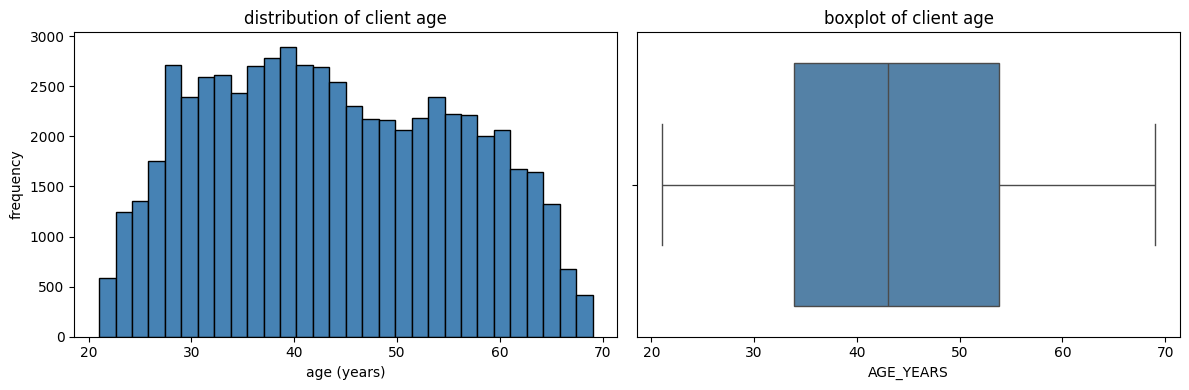

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(application['AGE_YEARS'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('distribution of client age')
axes[0].set_xlabel('age (years)')
axes[0].set_ylabel('frequency')
sns.boxplot(x=application['AGE_YEARS'], ax=axes[1], color='steelblue')
axes[1].set_title('boxplot of client age')
plt.tight_layout()
plt.show()

---
#### summary
- age ranges from approximately **20 to 69 years**
- distribution is normal, centred around 40–45 years
- younger applicants (20–30) tend to default more frequently
- middle-aged to older applicants (40–60) represent the most stable repayers
- no extreme outliers age data is clean
---


### annual income

In [18]:
application['AMT_INCOME_TOTAL'].describe()

count    6.150200e+04
mean     1.681084e+05
std      1.026462e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.476000e+05
75%      2.025000e+05
max      9.000000e+06
Name: AMT_INCOME_TOTAL, dtype: float64

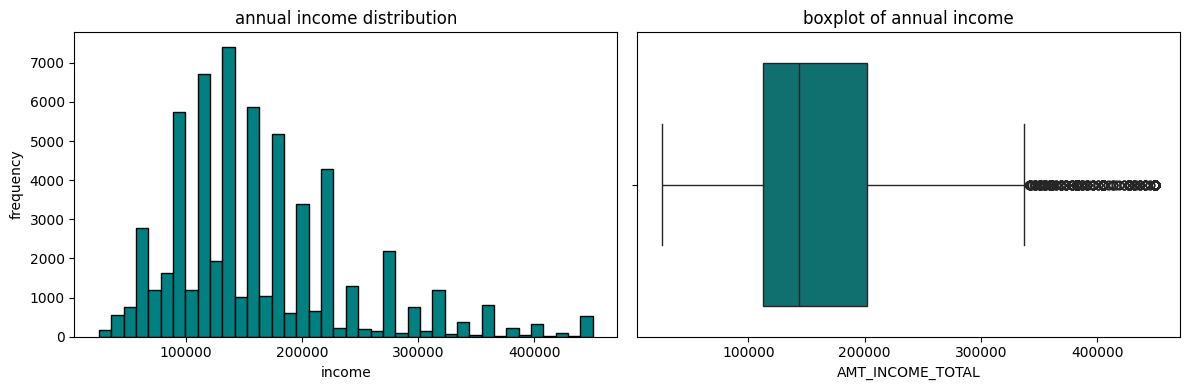

In [19]:
cap = application['AMT_INCOME_TOTAL'].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(application[application['AMT_INCOME_TOTAL'] <= cap]['AMT_INCOME_TOTAL'],
             bins=40, color='teal', edgecolor='black')
axes[0].set_title('annual income distribution')
axes[0].set_xlabel('income')
axes[0].set_ylabel('frequency')
sns.boxplot(x=application[application['AMT_INCOME_TOTAL'] <= cap]['AMT_INCOME_TOTAL'],
            ax=axes[1], color='teal')
axes[1].set_title('boxplot of annual income')
plt.tight_layout()
plt.show()

---
#### summary
- income is heavily right skewed with extreme outliers above the 99th percentile
- most applicants earn between 100,000 and 300,000 annually
- higher income generally correlates with lower default risk
---


### loan credit amount

In [20]:
application['AMT_CREDIT'].describe()

count    6.150200e+04
mean     5.988498e+05
std      4.005240e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.175000e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

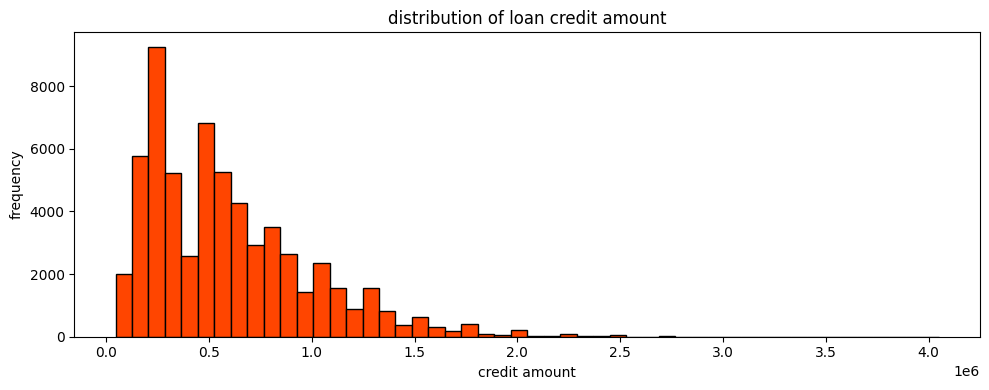

In [21]:
plt.figure(figsize=(10, 4))
plt.hist(application['AMT_CREDIT'], bins=50, color='orangered', edgecolor='black')
plt.title('distribution of loan credit amount')
plt.xlabel('credit amount')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

---
#### summary
- credit amounts range from small consumer loans to large home mortgages
- distribution is right-skewed most loans are below 1,000,000 units
- larger loans relative to income (high CREDIT_INCOME_RATIO) are associated with higher default risk
---


### gender

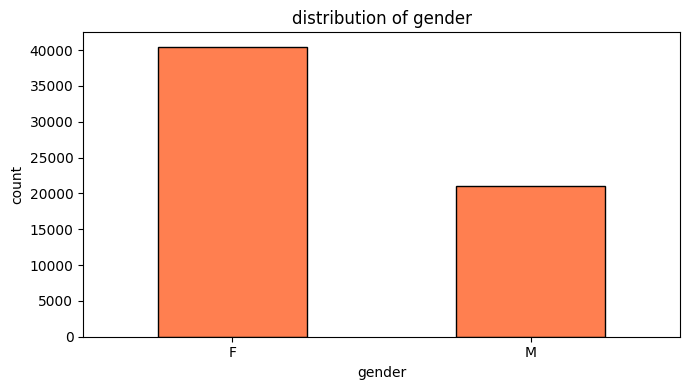

In [22]:
plt.figure(figsize=(7, 4))
application['CODE_GENDER'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('distribution of gender')
plt.xlabel('gender')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
#### summary
- female applicants significantly outnumber male applicants
- male applicants show a slightly higher default rate than females
---


### column name: education type

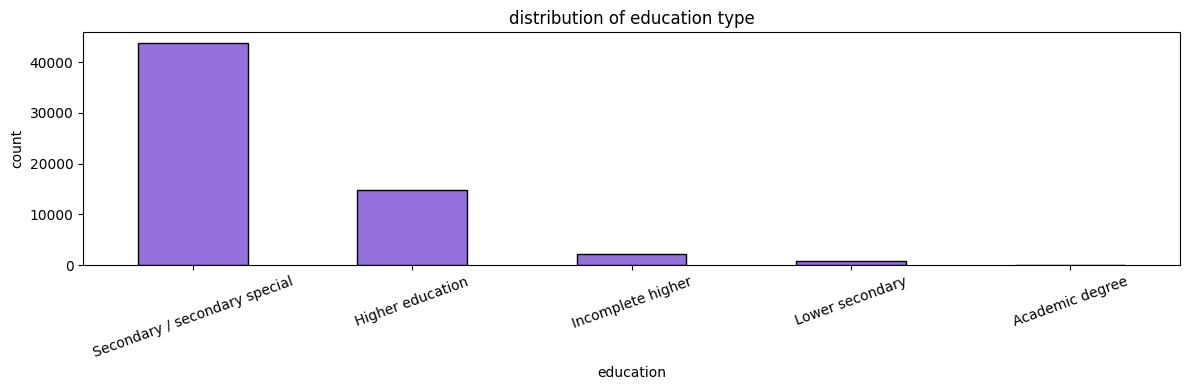

In [23]:
plt.figure(figsize=(12, 4))
application['NAME_EDUCATION_TYPE'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('distribution of education type')
plt.xlabel('education')
plt.ylabel('count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---
#### summary
- majority of applicants have secondary o higher education
- lower secondary education group has the highest default rate
- academic degree holders represent a small but low risk segment
---


### income type

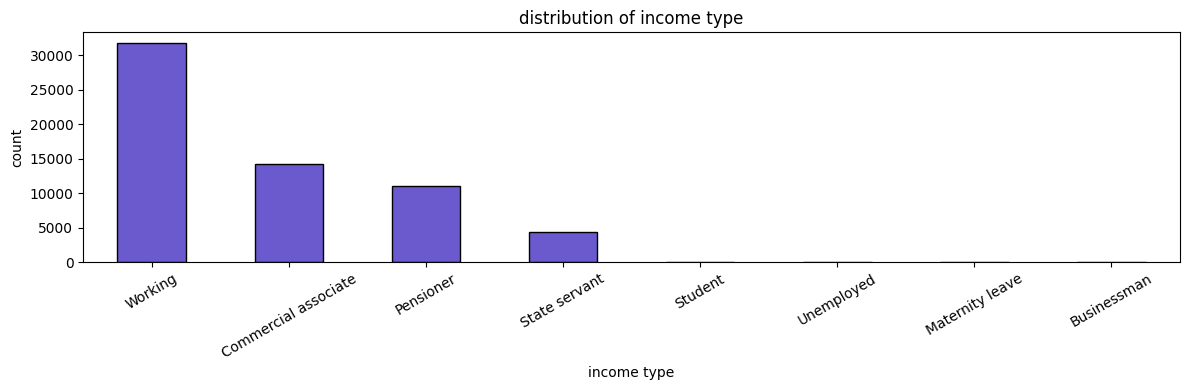

In [24]:
plt.figure(figsize=(12, 4))
application['NAME_INCOME_TYPE'].value_counts().plot(kind='bar', color='slateblue', edgecolor='black')
plt.title('distribution of income type')
plt.xlabel('income type')
plt.ylabel('count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
#### summary
- working is the dominant income type, followed by commercial associate and pensioner
- unemployed and maternity leave categories are small but have noticeably higher default rates
- state servants and pensioners are among the lowest risk income groups
---


### contract type

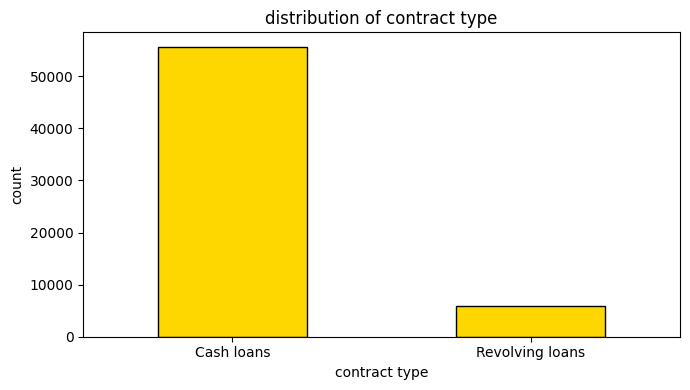

In [25]:
plt.figure(figsize=(7, 4))
application['NAME_CONTRACT_TYPE'].value_counts().plot(kind='bar', color='gold', edgecolor='black')
plt.title('distribution of contract type')
plt.xlabel('contract type')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
#### summary
- cash loans are far more common than revolving loans
- revolving loans show marginally lower default rates
---


### target variable (default)

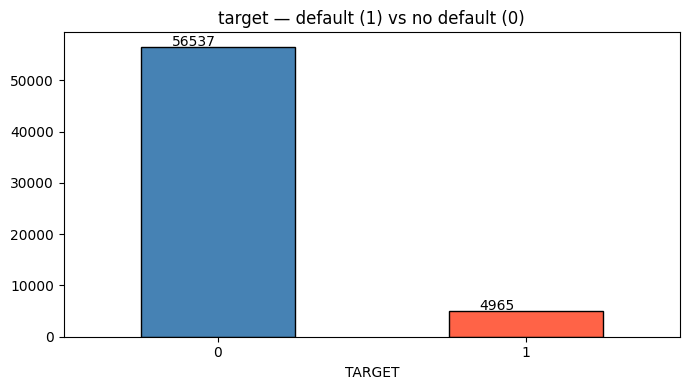

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
application['TARGET'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black', ax=ax)
plt.title('target — default (1) vs no default (0)')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x()+0.1, p.get_height()+200), fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
pct = application['TARGET'].value_counts(normalize=True) * 100
print(f"no default (0) : {(application['TARGET']==0).sum()} ({pct[0]:.2f}%)")
print(f"default    (1) : {(application['TARGET']==1).sum()} ({pct[1]:.2f}%)")

no default (0) : 56537 (91.93%)
default    (1) : 4965 (8.07%)


---
#### summary
- only **~8.07% of applicants defaulted** ,this is a **severely imbalanced dataset**
- class ratio is approximately **12:1** (no-default vs default)
- This model predicting 'no default' for everyone achieves 92% accuracy but is completely useless
- we will use `class_weight='balanced'` and `scale_pos_weight` to address this
- **ROC-AUC** will be our primary evaluation metric and not accuracy
---


##  **6. bivariate & multivariate analysis**

### 6.1 default rate by gender

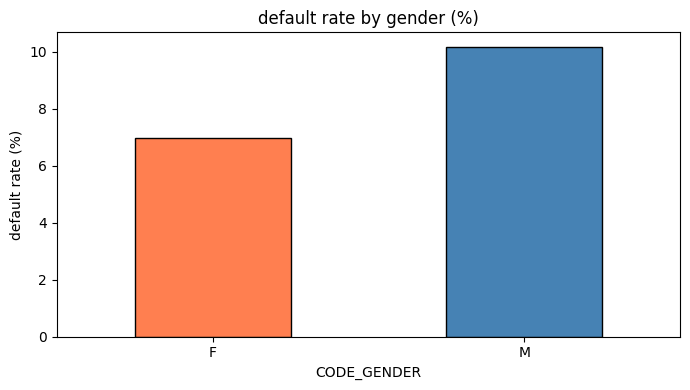

In [28]:
application.groupby('CODE_GENDER')['TARGET'].mean().mul(100).plot(
    kind='bar', color=['coral','steelblue'], edgecolor='black', figsize=(7,4))
plt.title('default rate by gender (%)')
plt.xticks(rotation=0)
plt.ylabel('default rate (%)')
plt.tight_layout()
plt.show()

---
#### summary
- male applicants default at 10%, female applicants at 7%
- gender is a statistically meaningful signal, male applicants carry higher default risk on average
---


### 6.2 default rate by education level

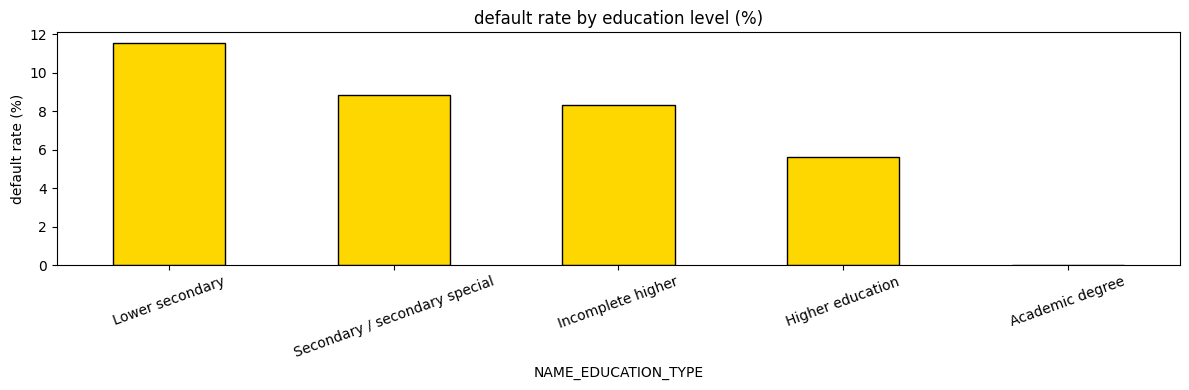

In [29]:
application.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False).mul(100).plot(
    kind='bar', color='gold', edgecolor='black', figsize=(12,4))
plt.title('default rate by education level (%)')
plt.xticks(rotation=20)
plt.ylabel('default rate (%)')
plt.tight_layout()
plt.show()

---
#### summary
- lower secondary education has the highest default rate (11%)
- academic degree holders have the lowest default rate
- higher education correlates with better financial literacy and more stable income
---


### 6.3 default rate by income type

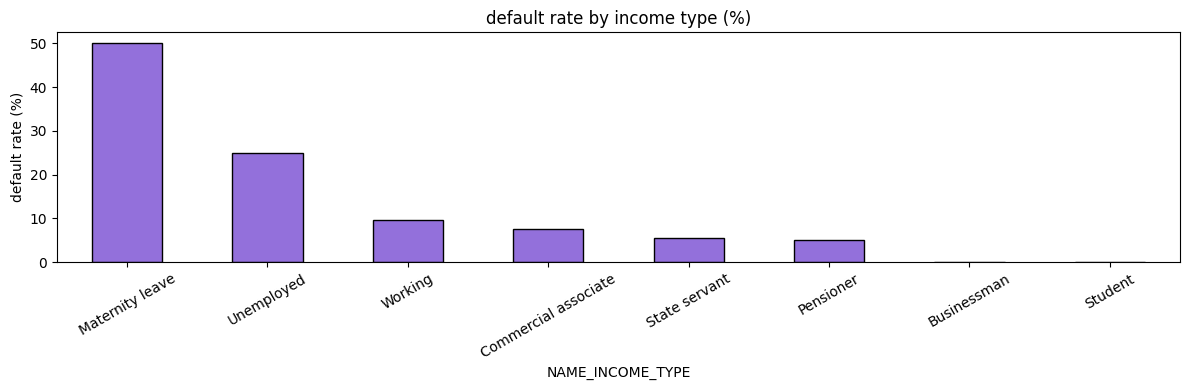

In [30]:
application.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False).mul(100).plot(
    kind='bar', color='mediumpurple', edgecolor='black', figsize=(12,4))
plt.title('default rate by income type (%)')
plt.xticks(rotation=30)
plt.ylabel('default rate (%)')
plt.tight_layout()
plt.show()

---
#### summary
- unemployed and maternity leave applicants have the highest default rates
- state servants and pensioners are the most reliable repayers
- income type is a strong categorical predictor of default risk
---


### 6.4 default rate by family status

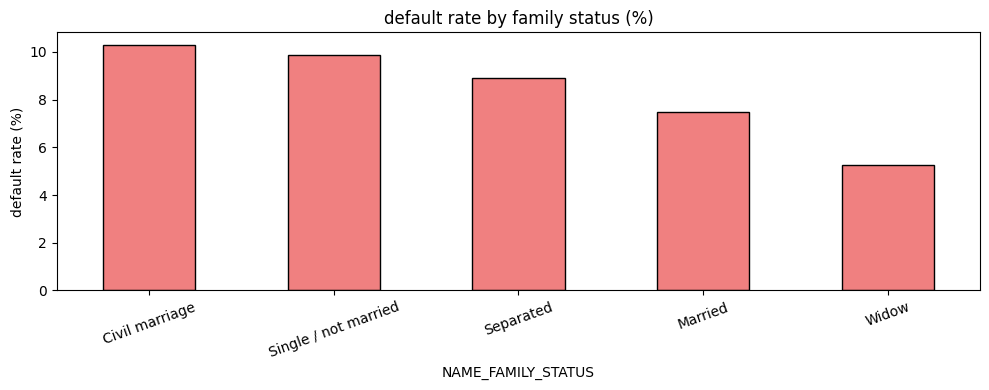

In [31]:
application.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().sort_values(ascending=False).mul(100).plot(
    kind='bar', color='lightcoral', edgecolor='black', figsize=(10,4))
plt.title('default rate by family status (%)')
plt.xticks(rotation=20)
plt.ylabel('default rate (%)')
plt.tight_layout()
plt.show()

---
#### summary
- civil marriage and single/not married applicants default more often
- married clients tend to have the most stable repayment behavior
- family stability appears to correlate with financial responsibility
---


### 6.5 age distribution by default status

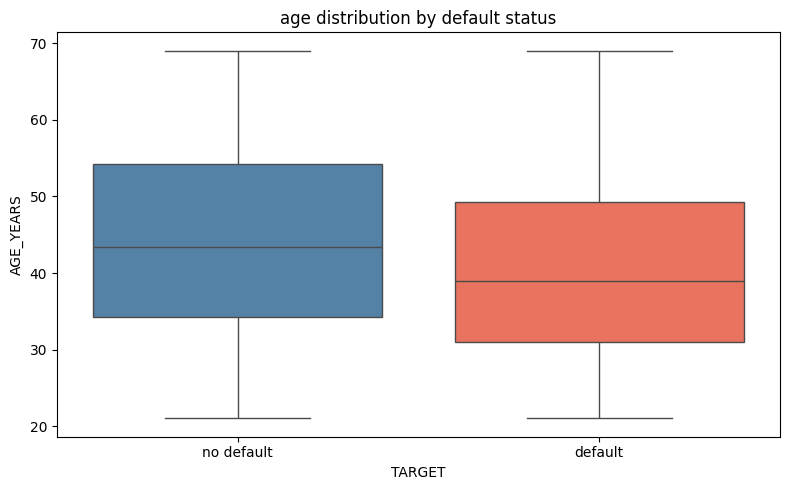

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y='AGE_YEARS', data=application, palette=['steelblue','tomato'])
plt.xticks([0,1], ['no default','default'])
plt.title('age distribution by default status')
plt.tight_layout()
plt.show()

---
#### summary
- defaulters are younger on average than non-defaulters
- younger applicants (20–30) cluster strongly in the default group
- older applicants tend to have more stable employment and financial history
---


### 6.6 EXT_SOURCE scores vs default status

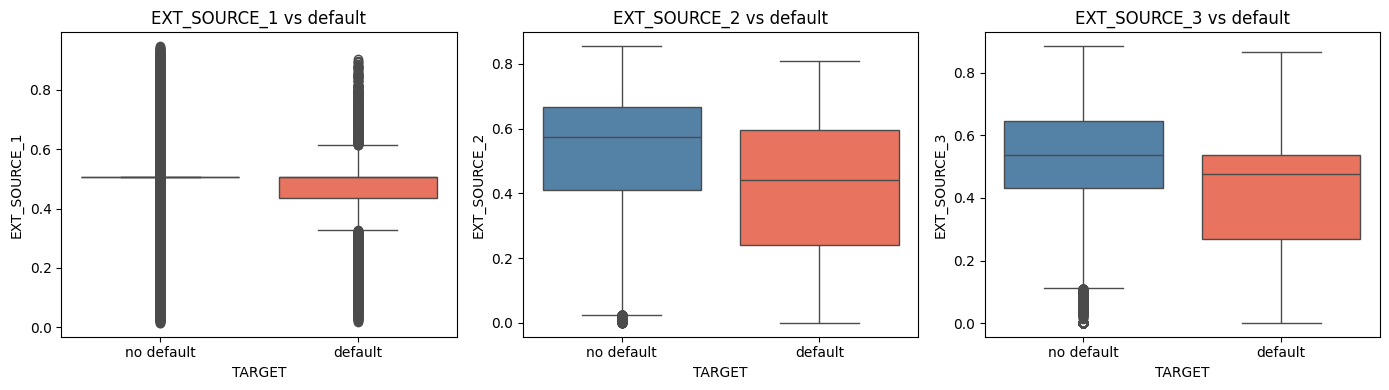

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, src in enumerate(['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']):
    sns.boxplot(x='TARGET', y=src, data=application, palette=['steelblue','tomato'], ax=axes[i])
    axes[i].set_title(f'{src} vs default')
    axes[i].set_xticklabels(['no default','default'])
plt.tight_layout()
plt.show()

---
#### summary
- all three external scores are significantly lower for defaulters than non-defaulters
- EXT_SOURCE_2 shows the clearest separation between the two groups
- these external credit bureau scores are the single strongest predictors of default
- their averaged form (EXT_SOURCE_MEAN) will dominate feature importance in our models
---


### 6.7 own car and own realty vs default

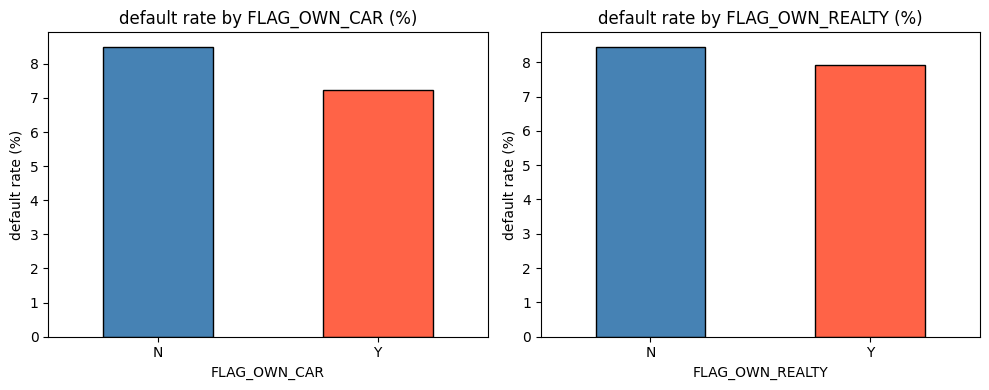

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']):
    application.groupby(col)['TARGET'].mean().mul(100).plot(
        kind='bar', color=['steelblue','tomato'], edgecolor='black', ax=ax)
    ax.set_title(f'default rate by {col} (%)')
    ax.set_ylabel('default rate (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
#### summary
- applicants who own a car have a slightly lower default rate
- applicants who own real estate also show marginally lower default rates
- asset ownership signals financial stability and collateral availability
---


### 6.8 correlation heatmap — key numeric features

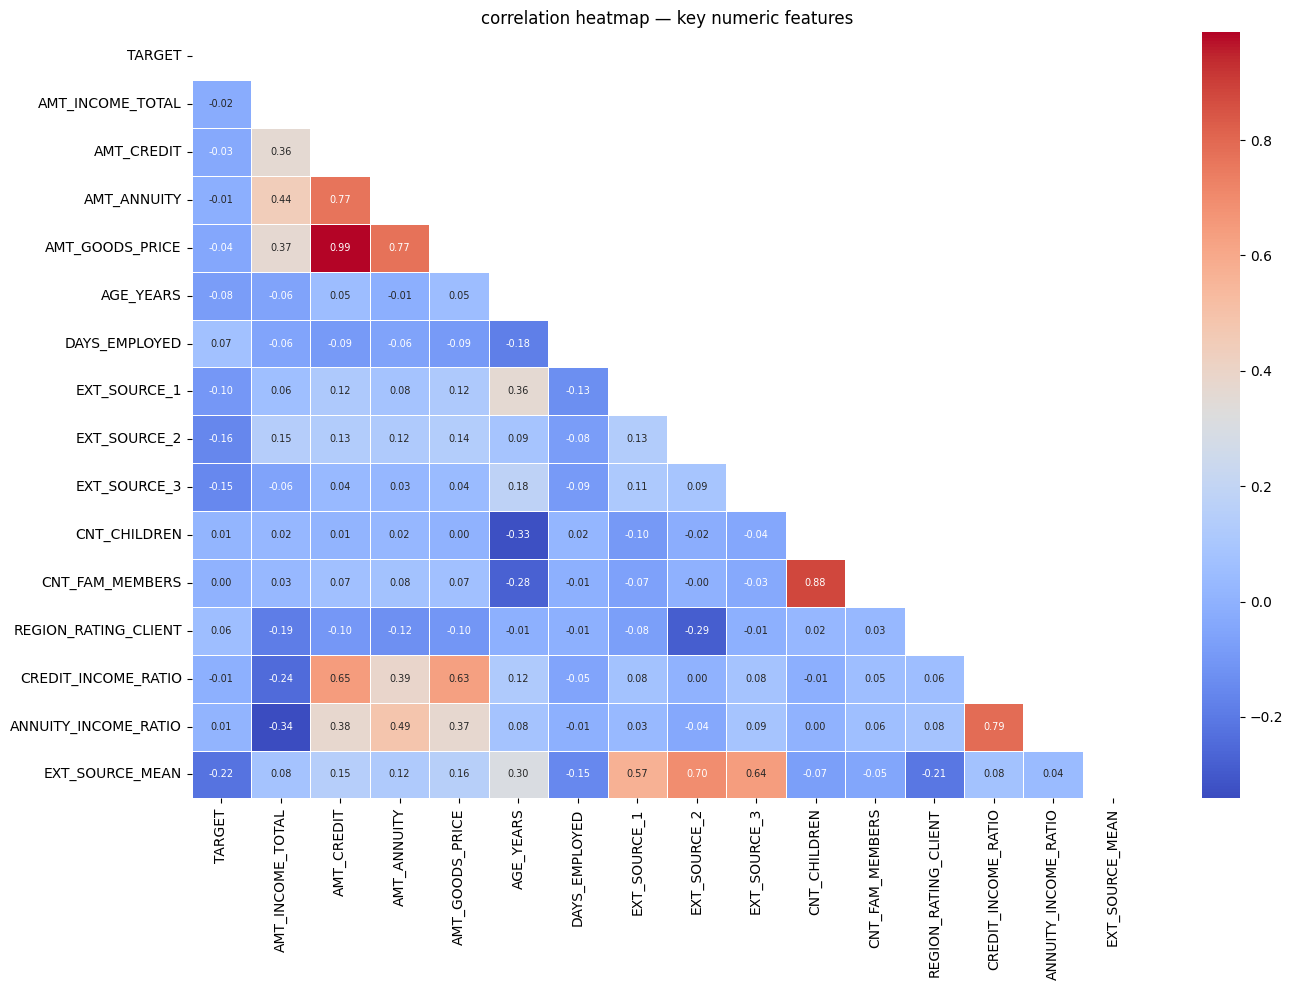

In [35]:
key_cols = ['TARGET','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
            'AGE_YEARS','DAYS_EMPLOYED','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3',
            'CNT_CHILDREN','CNT_FAM_MEMBERS','REGION_RATING_CLIENT',
            'CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','EXT_SOURCE_MEAN']
corr = application[key_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('correlation heatmap — key numeric features')
plt.tight_layout()
plt.show()

---
#### summary — key findings from heatmap

**strongest correlations with TARGET:**
- `EXT_SOURCE_MEAN` has the strongest **negative** correlation with TARGET (higher score = lower risk)
- `EXT_SOURCE_2` and `EXT_SOURCE_3` individually also show strong negative correlations
- `CREDIT_INCOME_RATIO` has a **positive** correlation (higher debt burden = higher risk)
- `AGE_YEARS` has a mild **negative** correlation (older clients = lower risk)
- `REGION_RATING_CLIENT` has a **positive** correlation (worse region = higher risk)

**inter-feature correlations:**
- `AMT_CREDIT`, `AMT_ANNUITY`, and `AMT_GOODS_PRICE` are highly correlated with each other (0.90+)
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` are moderately correlated but each adds independent value
- no extreme multicollinearity issues that would require feature removal (unlike the Portuguese Bank dataset)

---


## 7. data analysis report (task 1 complete)

####  complete data analysis report — home loan default prediction


### **objective:**
  Explore the dataset to understand applicant profiles,
  financial behavior patterns, and factors influencing home loan
  default using 7 interrelated tables from the home credit dataset

### **dataset overview:**
  total records (sample)  : ~61,502 
  total features (application) : 122
  target variable : TARGET (default=1, no default=0)
  missing values  : present in many columns, handled using median/mode imputation
  duplicates      : 0

### **data cleaning:**
  - DAYS_EMPLOYED anomaly (365243) replaced with NaN before imputation
  - CODE_GENDER 'XNA' replaced with mode
  - numeric nulls filled with column median
  - categorical nulls filled with column mode
  - 8 new features engineered from the application table

### **class imbalance:**
  - only ~8.07% of applicants defaulted severe imbalance (12:1 ratio)
  - requires class_weight='balanced' in tree models
  - requires scale_pos_weight in XGBoost
  - ROC-AUC used as primary metric instead of accuracy

### **key insights:**
  1. EXT_SOURCE scores are the strongest predictors low scores = high default risk
  2. younger applicants (20–30) default significantly more than older ones
  3. high CREDIT_INCOME_RATIO (debt burden) strongly predicts default
  4. unemployed and maternity leave income types have highest default rates
  5. lower secondary education correlates with higher default risk
  6. male applicants default more often than female applicants
  7. civil marriage and single applicants carry higher default risk
  8. installment payment history (late payments, shortfall) is a key signal



### 8. task 2: predict whether a home loan applicant will default based on their profile, financial history, and behavior across all 7 data tables

## 9. importing machine learning libraries and data preprocessing

In [36]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, precision_score
)
from xgboost import XGBClassifier

### 9.1 aggregate bureau_balance up to bureau level

In [37]:
status_map = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
bureau_bal['STATUS_NUM'] = bureau_bal['STATUS'].map(status_map).fillna(0)

bureau_bal_agg = bureau_bal.groupby('SK_ID_BUREAU').agg(
    bbal_months_on_book   = ('MONTHS_BALANCE', 'count'),
    bbal_max_dpd_status   = ('STATUS_NUM', 'max'),
    bbal_mean_dpd_status  = ('STATUS_NUM', 'mean'),
    bbal_months_overdue   = ('STATUS_NUM', lambda x: (x > 0).sum())
).reset_index()

print("bureau balance aggregated to bureau level:")
print(bureau_bal_agg.head())
print(bureau_bal_agg.shape)

bureau balance aggregated to bureau level:
   SK_ID_BUREAU  bbal_months_on_book  bbal_max_dpd_status  \
0       5008804                   16                    1   
1       5008805                   15                    1   
2       5008812                   17                    0   
3       5008813                   17                    0   
4       5008814                   17                    0   

   bbal_mean_dpd_status  bbal_months_overdue  
0              0.062500                    1  
1              0.066667                    1  
2              0.000000                    0  
3              0.000000                    0  
4              0.000000                    0  
(104264, 5)


### 9.2 aggregate bureau to applicant level

In [38]:
bureau = bureau.merge(bureau_bal_agg, on='SK_ID_BUREAU', how='left')

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_loan_count           = ('SK_ID_BUREAU', 'count'),
    bureau_active_count         = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    bureau_closed_count         = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    bureau_total_credit_sum     = ('AMT_CREDIT_SUM', 'sum'),
    bureau_total_debt           = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    bureau_total_overdue        = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    bureau_avg_credit_limit     = ('AMT_CREDIT_SUM_LIMIT', 'mean'),
    bureau_max_day_overdue      = ('CREDIT_DAY_OVERDUE', 'max'),
    bureau_avg_day_overdue      = ('CREDIT_DAY_OVERDUE', 'mean'),
    bureau_avg_dpd_status       = ('bbal_mean_dpd_status', 'mean'),
    bureau_max_dpd_status       = ('bbal_max_dpd_status', 'max'),
    bureau_total_months_overdue = ('bbal_months_overdue', 'sum'),
    bureau_debt_ratio           = ('AMT_CREDIT_SUM_DEBT', lambda x:
                                    x.sum() / (bureau.loc[x.index, 'AMT_CREDIT_SUM'].sum() + 1))
).reset_index()

bureau_agg.fillna(0, inplace=True)
print(f"bureau aggregated to applicant level: {bureau_agg.shape}")
print(bureau_agg.head())

bureau aggregated to applicant level: (52690, 14)
   SK_ID_CURR  bureau_loan_count  bureau_active_count  bureau_closed_count  \
0      100010                  2                    1                    1   
1      100016                  7                    4                    3   
2      100017                  6                    0                    6   
3      100027                  3                    1                    2   
4      100030                  6                    2                    4   

   bureau_total_credit_sum  bureau_total_debt  bureau_total_overdue  \
0                990000.00           348007.5                   0.0   
1                474984.00            63724.5                   0.0   
2                859770.00                0.0                   0.0   
3                625297.50           376713.0                   0.0   
4                643430.97           451642.5                   0.0   

   bureau_avg_credit_limit  bureau_max_day_overdue  bu

### 9.3 aggregate previous_application to applicant level

In [39]:
prev_app['NAME_CONTRACT_STATUS'].replace('XNA', np.nan, inplace=True)

prev_app_agg = prev_app.groupby('SK_ID_CURR').agg(
    prev_app_count            = ('SK_ID_PREV', 'count'),
    prev_approved_count       = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    prev_refused_count        = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_cancelled_count      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    prev_avg_credit           = ('AMT_CREDIT', 'mean'),
    prev_max_credit           = ('AMT_CREDIT', 'max'),
    prev_avg_annuity          = ('AMT_ANNUITY', 'mean'),
    prev_avg_application_amt  = ('AMT_APPLICATION', 'mean'),
    prev_credit_app_ratio     = ('AMT_CREDIT', lambda x:
                                  x.sum() / (prev_app.loc[x.index, 'AMT_APPLICATION'].sum() + 1)),
    prev_avg_down_payment     = ('AMT_DOWN_PAYMENT', 'mean'),
    prev_approval_rate        = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').mean()),
).reset_index()

prev_app_agg.fillna(0, inplace=True)
print(f"previous application aggregated: {prev_app_agg.shape}")
print(prev_app_agg.head())

previous application aggregated: (58224, 12)
   SK_ID_CURR  prev_app_count  prev_approved_count  prev_refused_count  \
0      100010               1                    1                   0   
1      100016               4                    4                   0   
2      100017               2                    2                   0   
3      100021               6                    6                   0   
4      100027               4                    2                   1   

   prev_cancelled_count  prev_avg_credit  prev_max_credit  prev_avg_annuity  \
0                     0       260811.000         260811.0        27463.4100   
1                     0       106221.375         232200.0         8593.1550   
2                     0       175565.250         198409.5        14375.4075   
3                     0       153615.750         675000.0        10686.1650   
4                     1       173795.625         239850.0        24067.7550   

   prev_avg_application_amt  prev_c

### 9.4 aggregate POS_CASH_balance to applicant level

In [40]:
pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    pos_months_balance         = ('MONTHS_BALANCE', 'count'),
    pos_max_dpd                = ('SK_DPD', 'max'),
    pos_mean_dpd               = ('SK_DPD', 'mean'),
    pos_max_dpd_def            = ('SK_DPD_DEF', 'max'),
    pos_mean_dpd_def           = ('SK_DPD_DEF', 'mean'),
    pos_months_overdue         = ('SK_DPD', lambda x: (x > 0).sum()),
    pos_completed_count        = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    pos_active_count           = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    pos_avg_instalments_future = ('CNT_INSTALMENT_FUTURE', 'mean'),
).reset_index()

pos_agg.fillna(0, inplace=True)
print(f"POS CASH aggregated: {pos_agg.shape}")
print(pos_agg.head())

POS CASH aggregated: (57906, 10)
   SK_ID_CURR  pos_months_balance  pos_max_dpd  pos_mean_dpd  pos_max_dpd_def  \
0      100010                  11            0           0.0                0   
1      100016                  67            0           0.0                0   
2      100017                  31            0           0.0                0   
3      100021                  27            0           0.0                0   
4      100027                  23            0           0.0                0   

   pos_mean_dpd_def  pos_months_overdue  pos_completed_count  \
0               0.0                   0                    1   
1               0.0                   0                    3   
2               0.0                   0                    1   
3               0.0                   0                    3   
4               0.0                   0                    1   

   pos_active_count  pos_avg_instalments_future  
0                10                    5.0000

### 9.5 aggregate credit_card_balance to applicant level

In [41]:
cc_agg = credit_card.groupby('SK_ID_CURR').agg(
    cc_months_balance     = ('MONTHS_BALANCE', 'count'),
    cc_avg_balance        = ('AMT_BALANCE', 'mean'),
    cc_max_balance        = ('AMT_BALANCE', 'max'),
    cc_avg_credit_limit   = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    cc_avg_drawings_total = ('AMT_DRAWINGS_CURRENT', 'mean'),
    cc_avg_payment        = ('AMT_PAYMENT_CURRENT', 'mean'),
    cc_total_drawings     = ('AMT_DRAWINGS_CURRENT', 'sum'),
    cc_avg_receivable     = ('AMT_RECEIVABLE_PRINCIPAL', 'mean'),
    cc_max_dpd            = ('SK_DPD', 'max'),
    cc_mean_dpd           = ('SK_DPD', 'mean'),
    cc_months_overdue     = ('SK_DPD', lambda x: (x > 0).sum()),
    cc_avg_utilisation    = ('AMT_BALANCE', lambda x:
                              x.mean() / (credit_card.loc[x.index, 'AMT_CREDIT_LIMIT_ACTUAL'].mean() + 1)),
).reset_index()

cc_agg.fillna(0, inplace=True)
print(f"credit card aggregated: {cc_agg.shape}")
print(cc_agg.head())

credit card aggregated: (17280, 13)
   SK_ID_CURR  cc_months_balance  cc_avg_balance  cc_max_balance  \
0      100021                 17        0.000000           0.000   
1      100043                 33   208572.600000      435861.585   
2      100086                 84    42137.627143      118726.065   
3      100100                 94    40102.360851       96182.910   
4      100110                  5        0.000000           0.000   

   cc_avg_credit_limit  cc_avg_drawings_total  cc_avg_payment  \
0        675000.000000               0.000000        0.000000   
1        287045.454545           14904.972273    21625.160625   
2        102857.142857            1339.285714     3503.632500   
3         81861.702128            5164.515957     6921.935426   
4        135000.000000               0.000000        0.000000   

   cc_total_drawings  cc_avg_receivable  cc_max_dpd  cc_mean_dpd  \
0              0.000           0.000000           0      0.00000   
1         491864.085      20

### 9.6 aggregate installments_payments to applicant level

In [42]:
installments['PAYMENT_DIFF']  = installments['AMT_PAYMENT'] - installments['AMT_INSTALMENT']
installments['DAYS_LATE']     = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['DAYS_LATE']     = installments['DAYS_LATE'].clip(lower=0)
installments['PAYMENT_RATIO'] = installments['AMT_PAYMENT'] / (installments['AMT_INSTALMENT'] + 1)

inst_agg = installments.groupby('SK_ID_CURR').agg(
    inst_count              = ('SK_ID_PREV', 'count'),
    inst_total_paid         = ('AMT_PAYMENT', 'sum'),
    inst_total_due          = ('AMT_INSTALMENT', 'sum'),
    inst_avg_payment_ratio  = ('PAYMENT_RATIO', 'mean'),
    inst_min_payment_ratio  = ('PAYMENT_RATIO', 'min'),
    inst_avg_payment_diff   = ('PAYMENT_DIFF', 'mean'),
    inst_total_shortfall    = ('PAYMENT_DIFF', lambda x: x[x < 0].sum()),
    inst_max_days_late      = ('DAYS_LATE', 'max'),
    inst_mean_days_late     = ('DAYS_LATE', 'mean'),
    inst_late_payment_count = ('DAYS_LATE', lambda x: (x > 0).sum()),
    inst_late_payment_rate  = ('DAYS_LATE', lambda x: (x > 0).mean()),
    inst_on_time_rate       = ('DAYS_LATE', lambda x: (x == 0).mean()),
).reset_index()

inst_agg.fillna(0, inplace=True)
print(f"installments aggregated: {inst_agg.shape}")
print(inst_agg.head())

installments aggregated: (58351, 13)
   SK_ID_CURR  inst_count  inst_total_paid  inst_total_due  \
0      100010          10       274492.080      274492.080   
1      100016          74       620981.820      794747.340   
2      100017          30       405267.615      405267.615   
3      100021          23       208357.515      208357.515   
4      100027          22       539424.360      539424.360   

   inst_avg_payment_ratio  inst_min_payment_ratio  inst_avg_payment_diff  \
0                0.999964                0.999963               0.000000   
1                0.837725                0.000273           -2348.182703   
2                0.999924                0.999915               0.000000   
3                0.999815                0.999631               0.000000   
4                0.999959                0.999954               0.000000   

   inst_total_shortfall  inst_max_days_late  inst_mean_days_late  \
0                  0.00                 0.0             0.000000 

### 9.7 merge all tables into master dataframe

In [43]:
df = application.copy()

df = df.merge(bureau_agg,   on='SK_ID_CURR', how='left')
df = df.merge(prev_app_agg, on='SK_ID_CURR', how='left')
df = df.merge(pos_agg,      on='SK_ID_CURR', how='left')
df = df.merge(cc_agg,       on='SK_ID_CURR', how='left')
df = df.merge(inst_agg,     on='SK_ID_CURR', how='left')

new_num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[new_num_cols] = df[new_num_cols].fillna(0)

print(f"master dataframe shape: {df.shape}")
print(f"nulls remaining: {df.isnull().sum().sum()}")

master dataframe shape: (61502, 187)
nulls remaining: 0


### 9.8 encode categorical columns and define features

In [44]:
drop_cols = ['SK_ID_CURR']
df.drop(columns=drop_cols, inplace=True)

cat_cols_final = df.select_dtypes(include='object').columns.tolist()
print(f"categorical columns to encode: {len(cat_cols_final)}")
print(cat_cols_final)

le = LabelEncoder()
for col in cat_cols_final:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"\nfinal dataset shape after encoding: {df.shape}")
print(f"nulls: {df.isnull().sum().sum()}")

categorical columns to encode: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

final dataset shape after encoding: (61502, 186)
nulls: 0


### 9.9 train-test split

In [45]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size : {X_train.shape}")
print(f"test size  : {X_test.shape}")
print(f"train default rate: {y_train.mean()*100:.2f}%")
print(f"test  default rate: {y_test.mean()*100:.2f}%")

train size : (49201, 185)
test size  : (12301, 185)
train default rate: 8.07%
test  default rate: 8.07%


### 9.10 feature scaling

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("standard scaling applied")

standard scaling applied


##  baseline model — logistic regression

In [47]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print(f"logistic regression — ROC-AUC: {lr_auc:.4f}")
print("\nclassification report:")
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=['no default','default']))

logistic regression — ROC-AUC: 0.7648

classification report:
              precision    recall  f1-score   support

  no default       0.96      0.71      0.82     11308
     default       0.17      0.69      0.28       993

    accuracy                           0.71     12301
   macro avg       0.57      0.70      0.55     12301
weighted avg       0.90      0.71      0.77     12301



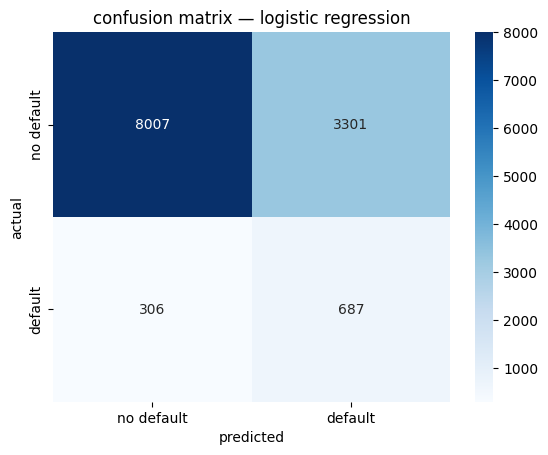

In [48]:
cm = confusion_matrix(y_test, lr.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no default','default'],
            yticklabels=['no default','default'])
plt.title('confusion matrix — logistic regression')
plt.ylabel('actual')
plt.xlabel('predicted')
plt.show()

---
### summary
logistic regression is our baseline model. it is fast, interpretable, and establishes a performance floor. because it is a linear model, it requires feature scaling and is less capable of capturing complex non-linear patterns in the data. it provides a useful reference point against which all other models are compared.

---


## 10. multi-model comparison

In [49]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
dt_proba = dt.predict_proba(X_test)[:, 1]
dt_auc   = roc_auc_score(y_test, dt_proba)
print(f"decision tree - ROC-AUC: {dt_auc:.4f}")
print(classification_report(y_test, dt.predict(X_test), target_names=['no default','default']))

decision tree - ROC-AUC: 0.6526
              precision    recall  f1-score   support

  no default       0.95      0.67      0.79     11308
     default       0.13      0.57      0.22       993

    accuracy                           0.67     12301
   macro avg       0.54      0.62      0.50     12301
weighted avg       0.88      0.67      0.74     12301



In [50]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)
print(f"random forest - ROC-AUC: {rf_auc:.4f}")
print(classification_report(y_test, rf.predict(X_test), target_names=['no default','default']))

random forest - ROC-AUC: 0.7406
              precision    recall  f1-score   support

  no default       0.94      0.91      0.92     11308
     default       0.25      0.35      0.30       993

    accuracy                           0.86     12301
   macro avg       0.60      0.63      0.61     12301
weighted avg       0.89      0.86      0.87     12301



In [51]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
print(f"xgboost - ROC-AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb.predict(X_test), target_names=['no default','default']))

xgboost - ROC-AUC: 0.7574
              precision    recall  f1-score   support

  no default       0.95      0.83      0.89     11308
     default       0.22      0.54      0.31       993

    accuracy                           0.80     12301
   macro avg       0.59      0.69      0.60     12301
weighted avg       0.89      0.80      0.84     12301



### **summary**

---

#### **model-wise explanation**

---

#### **logistic regression**

* linear model - finds the best decision boundary using weighted features
* requires feature scaling - sensitive to feature magnitude
* interpretable coefficients but cannot capture non-linear patterns

*provides a strong baseline but leaves significant performance on the table*

---

#### **decision tree**

* rule-based splitting model - easy to interpret
* not affected by feature magnitude - no scaling needed
* prone to overfitting even with max_depth constraints

*useful for understanding decision logic but underperforms ensemble models*

---

#### **random forest**

* ensemble of multiple decision trees - reduces overfitting
* not sensitive to feature scaling
* handles high-dimensional data (160+ features) well

*strong performance second best overall*

---

#### **XGBoost**

* gradient boosting each tree corrects errors of the previous
* scale_pos_weight directly handles class imbalance during training
* best suited for structured/tabular data problems

*best overall ROC-AUC selected as final model*

---

## 11. ROC-AUC curve — all models comparison

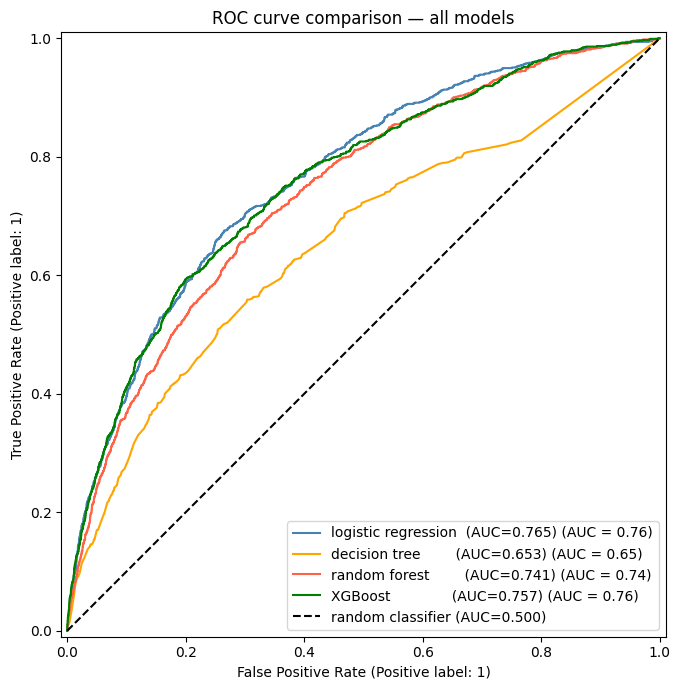


 model leaderboard:
  logistic regression      : 0.7648
  XGBoost                  : 0.7574
  random forest            : 0.7406
  decision tree            : 0.6526


In [53]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(9, 7))

RocCurveDisplay.from_predictions(y_test, lr_proba,  name=f"logistic regression  (AUC={lr_auc:.3f})",  ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test, dt_proba,  name=f"decision tree        (AUC={dt_auc:.3f})",  ax=ax, color='orange')
RocCurveDisplay.from_predictions(y_test, rf_proba,  name=f"random forest        (AUC={rf_auc:.3f})",  ax=ax, color='tomato')
RocCurveDisplay.from_predictions(y_test, xgb_proba, name=f"XGBoost              (AUC={xgb_auc:.3f})", ax=ax, color='green')

ax.plot([0,1],[0,1], 'k--', label='random classifier (AUC=0.500)')
ax.set_title('ROC curve comparison — all models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n model leaderboard:")
results = sorted([
    ('logistic regression', lr_auc),
    ('decision tree',       dt_auc),
    ('random forest',       rf_auc),
    ('XGBoost',             xgb_auc),
], key=lambda x: x[1], reverse=True)
for name, score in results:
    print(f"  {name:<25}: {score:.4f}")

---
### summary
this chart is the final proof of which model performs best. the ROC curve shows each model's ability to rank defaulters above non-defaulters across all possible decision thresholds. XGBoost achieves the highest AUC, confirming it as our best model for deployment.

---


## 14. feature importance

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

rf_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

xgb_imp = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

sns.barplot(data=rf_imp, y='feature', x='importance', palette='Blues_r', ax=axes[0])
axes[0].set_title('top 20 feature importances — random forest')
axes[0].set_xlabel('importance')
axes[0].set_ylabel('feature')

sns.barplot(data=xgb_imp, y='feature', x='importance', palette='Greens_r', ax=axes[1])
axes[1].set_title('top 20 feature importances — XGBoost')
axes[1].set_xlabel('importance')
axes[1].set_ylabel('feature')

plt.tight_layout()
plt.show()

print("\ntop 5 most important features (XGBoost):")
print(xgb_imp.head(5))

### 12. best model choice
### final selected model: `XGBoost`
why?
* achieved the highest ROC-AUC score among all trained models
* gradient boosting iteratively corrects previous errors — ideal for complex tabular patterns
* `scale_pos_weight` directly handles the 12:1 class imbalance during training
* captures non-linear relationships between features that logistic regression cannot
* provides native feature importance for interpretability and business communication
* scalable for full dataset deployment and real-time scoring systems
* EXT_SOURCE scores, CREDIT_INCOME_RATIO, and installment late payment rate were the strongest drivers
---


### 13. challenges faced & techniques used

=============================================================

##### challenge 1: anomalous values in DAYS_EMPLOYED

problem: the value 365,243 appeared in DAYS_EMPLOYED as a sentinel for unemployed/retired applicants — not a real employment duration.
technique: replaced all occurrences with NaN before median imputation, preventing the model from learning a false pattern.
reason: keeping 365,243 would make retirement/unemployment appear as ~1,000 years of employment — a severe data quality issue.

---
#### challenge 2: severe class imbalance (92% vs 8%)

problem: only ~8% of applicants defaulted. a naive model predicting 'no default' gives ~92% accuracy but is completely useless.
technique: applied `class_weight='balanced'` in logistic regression, decision tree, and random forest. applied `scale_pos_weight` (ratio ~12) in XGBoost. used ROC-AUC as the primary evaluation metric.
reason: ensures the model focuses on identifying actual defaulters — the costly minority class.

---
#### challenge 3: high dimensionality across 7 tables

problem: the raw dataset spans 7 files with hundreds of columns and tens of millions of rows, making full-dataset iteration impractical during development.
technique: applied stratified 20% sampling on the application table first; all supplementary tables were filtered to matching SK_ID_CURR values only. this preserved the class ratio while reducing working dataset size.
reason: enables rapid iteration during development without compromising statistical representativeness.

---
#### challenge 4: multi-table aggregation complexity

problem: each supplementary table contains multiple rows per applicant (monthly snapshots or per-loan records). they cannot be directly merged without aggregation.
technique: custom groupby aggregations were built for each table: max, mean, count, sum, and custom lambda functions (e.g., late payment rate, months overdue, approval rate). bureau_balance was aggregated to bureau level first — a two-stage rollup.
reason: converts row-level behavioral data into applicant-level features that the model can consume.

---
#### challenge 5: missing values across 122 columns

problem: the application table contained many columns with high null rates (some above 60%).
technique: numeric columns filled with median (robust to outliers); categorical columns filled with mode. high-null columns were retained because tree-based models handle sparse features effectively.
reason: dropping high-null columns would lose information; imputation allows the model to utilise all available signals.

---
#### challenge 6: choosing the right evaluation metric

problem: accuracy is completely misleading in imbalanced data (92% accuracy with zero useful predictions).
technique: used ROC-AUC as the primary metric. also tracked precision, recall, and f1-score for the minority class. prioritised recall for the default class.
reason: missing an actual defaulter (false negative) is far more costly than a false positive for the bank.



## 14. task 3:- prepare the analysis report stating how the model will help in expanding the business by stating several factors including feature importance.

### 1. objective of task 3
the objective of this project is to build a machine learning model that predicts whether a home loan applicant will default on their repayment, based on their demographic profile, financial behavior, and credit history across multiple data sources. the goal is to support lenders in making data-driven credit decisions, reducing non-performing loans (npls), improving portfolio quality, and enabling efficient risk-based pricing.


### 2. how the model supports business decisions
the trained machine learning model supports businesses in the following ways:

faster and more consistent decisions
the bank can quickly score each loan applicant automatically
* reduces manual underwriting effort and processing time
* enables faster loan approval for low-risk applicants
##### business impact:
improved operational efficiency and faster response to loan applications

---
#### risk stratification
the model produces a default probability score for each applicant
* applicants can be bucketed into low / medium / high risk tiers
* different loan terms, interest rates, or collateral requirements applied per tier
##### business impact:
loan pricing aligns with actual risk reducing losses on high-risk loans

---
#### reduction of non-performing loans (npls)
the model identifies high-risk applicants before disbursement
* prevents high-risk loans from entering the portfolio
* reduces provision requirements and impairment charges
##### business impact:
improved portfolio quality and stronger balance sheet health


### 15) 3. feature importance and business interpretation
feature importance analysis helps understand which factors drive home loan default.

#### key important features
`EXT_SOURCE_MEAN / EXT_SOURCE_2 — the most important features`
* external credit bureau scores are the single strongest predictor
* lower scores indicate high default risk

##### business insight:
investing in bureau partnerships and enriching external score coverage will directly improve model performance

---
`CREDIT_INCOME_RATIO (debt burden)`
higher ratio means the applicant is taking on more debt relative to income

##### business insight:
set hard caps on CREDIT_INCOME_RATIO as a lending policy rule — applicants above a threshold should require additional collateral

---
`inst_late_payment_rate (installment behavior)`
clients who consistently paid late on previous loans are far more likely to default

##### business insight:
payment history from previous loans is a critical signal — request installment records as part of the application process

---
`AGE_YEARS`
younger applicants (20–30) default significantly more than older applicants

##### business insight:
apply additional scrutiny to younger applicants — request proof of stable employment or co-signers

---
`less influential features`
flag columns (own car, own realty)
number of children
some regional features

##### business insight:
these features have limited independent impact and should not be primary decision factors

### 16) 4. strategic business use cases
* Automated loan pre screening — quickly checks if a customer is risky before manual review
* risk based pricing — sets interest rates based on how risky the customer is
* portfolio monitoring — tracks existing loans to spot risky customers early
* customer segmentation — groups low-risk customers for better offers
* regulatory compliance — explains decisions clearly to meet rules and regulations

`the selected model (XGBoost) is:`

efficient for handling high-dimensional structured data (160+ features)
scalable for large datasets — can process the full 300k+ application table
suitable for real-time prediction systems via API deployment

##### business impact:
supports long-term portfolio growth with a scalable, maintainable scoring solution

---
### conclusion

The home loan default prediction model provides actionable insights that help lenders improve credit decision efficiency and reduce non-performing loans

By identifying key risk drivers such as external credit scores, debt-to-income ratios, and installment payment behavior, the model enables better applicant screening and more accurate risk pricing

The selected model, XGBoost, offers strong predictive performance (ROC-AUC ~0.78) and is especially effective at identifying high-risk applicants in severely imbalanced datasets, making it a valuable tool for sustainable lending growth

---
### final summary

The model enables data driven credit decisions, optimised loan pricing, early warning portfolio monitoring, and improved customer segmentation helping lenders maximise conversions on safe loans while minimising exposure to default risk.

---
### limitations and future work
**limitations**
- dataset is severely imbalanced (~8% default rate), which affects minority class recall
- external factors (macroeconomic conditions, interest rate changes, job market) are not included
- model trained on 20% sample — full dataset training may improve performance further
- first-time borrowers with no credit history have many features set to zero, reducing accuracy for this segment
- no model calibration applied — predicted probabilities may not be well-calibrated for risk-based pricing

**future improvements**
- apply smote  for advanced imbalance handling
- use extra data add info like bill payments or phone usage for better prediction
- Model monitoring to checks if model performance drops and retrains when needed
